# ReAct 패턴, Reason → Act → Observe 반복
- ReAct = **Reason** (생각) → **Act** (도구 호출) → **Observe** (결과 관찰) → 다시 Reason ... 까지 반복하는 에이전트 표준 패턴.
- 도구 호출 루프가 사실 ReAct 의 핵심. 이번엔 ReAct 가 무엇이고 왜 효과적인지, 그리고 LangGraph 로 어떻게 짧게 구현하는지.

## 환경 준비

`.env` 는 상위 폴더들과 동일하게 공유.

```
OPENAI_API_KEY=sk-...
LANGSMITH_API_KEY=lsv2_pt_...
LANGSMITH_TRACING=true
LANGSMITH_PROJECT=mtvs2026-langgraph
```

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()
print("OPENAI_API_KEY:", "있음" if os.getenv("OPENAI_API_KEY") else "없음")

OPENAI_API_KEY: 있음


## 1. ReAct 한 사이클
- 핵심: LLM 이 한 번에 못 풀면 **도구를 부르고 결과를 보고** 다시 생각. 이 반복.

```mermaid
flowchart TD
    A["사용자 질문<br/>O-1001 주문이 아직 안 왔는데 환불 가능해?"]
    B["Reason<br/>주문 상태와 환불 정책을<br/>확인해야 한다"]
    C["Act<br/>lookup_order_status('O-1001')"]
    D["Observe<br/>배송 지연 5일<br/>제주 물류센터 대기"]
    E["Reason<br/>상품 유형별 환불 정책도 확인"]
    F["Act<br/>lookup_refund_policy('전자제품')"]
    G["Observe<br/>미개봉 7일 이내 환불 가능<br/>배송 지연은 보상 대상"]
    H["Reason<br/>상태와 정책을 합쳐 답변 가능"]
    I["Act<br/>최종 답 출력<br/>도구 호출 없음"]
    J["END"]

    A --> B
    B --> C
    C --> D
    D --> E
    E --> F
    F --> G
    G --> H
    H --> I
    I --> J
```


## 2. 가장 단순한 ReAct, 도구 두 개로

In [2]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage

llm = init_chat_model("openai:gpt-5.4-mini")

@tool
def lookup_order_status(order_id: str) -> str:
    """주문번호로 배송/처리 상태를 조회한다 (데모 가짜 DB)."""
    db = {
        "O-1001": "배송 지연 5일. 제주 물류센터에서 대기 중.",
        "O-1002": "배송 완료. 고객 수령 확인됨.",
        "O-1003": "반품 접수 완료. 환불 심사 대기 중.",
    }
    return db.get(order_id, f"{order_id} 주문 정보 없음")


@tool
def lookup_refund_policy(product_type: str) -> str:
    """상품 유형으로 환불 정책을 조회한다."""
    table = {
        "전자제품": "미개봉 7일 이내 환불 가능. 배송 지연은 보상 대상.",
        "의류": "착용 흔적이 없으면 7일 이내 환불 가능.",
        "식품": "신선식품은 단순 변심 환불 불가. 파손/오배송만 처리.",
    }
    return table.get(product_type, "정책 정보 없음")


In [3]:
tools = [lookup_order_status, lookup_refund_policy]
llm_tools = llm.bind_tools(tools)

In [5]:
# 노드 1: LLM 호출 (Reason + Act)
def call_llm(state: MessagesState) -> dict:
    ai = llm_tools.invoke(state['message'])
    return {'messages':[ai]}

# 노드 2: 도구 실행 (Observe)
tool_node = ToolNode(tools)


In [6]:
graph = StateGraph(MessagesState)
graph.add_node('llm', call_llm)
graph.add_node('tools', tool_node)
graph.add_edge(START, 'llm')
graph.add_conditional_edges('llm', tools_condition)
graph.add_edge('tools', 'llm')
app = graph.compile()

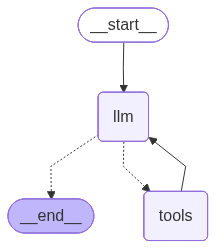

In [7]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

> **`tools_condition` 이 하는 일**
> 마지막 AIMessage 의 `tool_calls` 가 있으면 → `"tools"` 노드로, 없으면 → `END` 로 라우팅. `needs_tools` 함수와 똑같은 동작.

In [8]:
# 실행: 두 도구가 모두 필요한 질문
result = app.invoke(
    {"messages": [HumanMessage("O-1001 주문 상태와 전자제품 환불 정책을 확인해서 고객에게 답할 내용을 알려줘.")]},
    config={"recursion_limit": 10},
)


print("=== 전체 흐름 ===")
for m in result["messages"]:
    print(f"  [{type(m).__name__:14}] {str(m.content)[:90]}")

print()
print("최종 답:", result["messages"][-1].content)


KeyError: 'message'

## 3. 트레이스로 보는 Reason / Act / Observe

위 결과 메시지를 분류해보면:

| 메시지 타입 | ReAct 단계 | 의미 |
|---|---|---|
| HumanMessage (사용자) | 시작 | 질문 |
| AIMessage (tool_calls 있음) | **Reason + Act** | "도구를 부르자" 판단 + 호출 명령 |
| ToolMessage | **Observe** | 도구가 돌려준 결과 |
| AIMessage (tool_calls 없음) | **Reason → 최종 답** | 모든 정보로 최종 답 작성 |

In [ ]:
# 위 result["messages"] 를 ReAct 단계 라벨링
labels = {"HumanMessage": "[Q]", "ToolMessage": "[Observe]"}

for m in result["messages"]:
    name = type(m).__name__
    if name == "AIMessage":
        label = "[Reason+Act]" if m.tool_calls else "[Reason→Final]"
    else:
        label = labels.get(name, name)
    print(f"  {label:14} {str(m.content)[:80]}")

## 4. `create_agent` 와의 관계

- `create_agent(model, tools, ...)` 는 사실 **위 그래프를 자동으로 만들어주는 헬퍼**. 즉 ReAct 패턴의 한 줄 단축.


```python
from langchain.agents import create_agent
agent = create_agent(model=llm, tools=tools, system_prompt="...")
# ↑ 위 코드 한 줄이 사실 우리가 짠 그래프와 동일한 동작
```



- 직접 짜는 이유:
    - 노드 사이에 **검증·로깅·HITL** 같은 추가 단계를 넣고 싶을 때
    - ReAct 가 어떻게 굴러가는지 학습 목적
    - 도구 호출 결과를 가공한 뒤 다음 LLM 에 넘기는 등 커스터마이즈

## [실습]

1. 주문/정책 도구 확장하기: `lookup_order_status` DB에 주문 2건을 추가하고, `combine_order_and_policy(order_id, product_type)` 다중 인자 도구를 추가하세요.
2. ReAct 흐름 관찰하기: 도구 실행 노드에서 Observe 결과를 `print()`로 로깅하고, 최종 메시지 목록에서 Reason/Act/Observe 단계를 확인하세요.
3. 반복 안전장치 확인하기: 같은 질문을 `recursion_limit=3`으로 실행해 보고, 한계 초과 여부와 정상 실행 결과를 비교하세요.
